
>>> EPISODE 300 SUMMARY | Success=True | Path=['N0', 'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N19', 'N20', 'N21', 'N22', 'N33', 'N50', 'N51', 'N52', 'N67', 'N85', 'N98', 'N99', 'N116', 'N133', 'N145', 'N163', 'N179', 'N193'] | TotalDistance=26 | TotalReward=-125 | BestDistance=26 | BestReward=-225 | SuccessRate=95.0% | Epsilon=0.050
----------------------------------------------------------------------

FINAL ADJACENCY MATRIX SHAPE: (194, 194)

FINAL Q-TABLE (rows=nodes, cols=[UP, DOWN, LEFT, RIGHT]):
[[ -85.41  -55.49  -98.35   -6.76]
 [ -97.29  -97.3   -58.79   -5.81]
 [ -99.46  -85.14  -62.7    -4.97]
 [ -88.61  -79.29  -62.81   -3.77]
 [ -93.62  -81.7   -72.55   -2.09]
 [ -91.04  -81.08  -64.91    1.11]
 [ -88.39  -58.65  -69.42    3.02]
 [ -81.09  -96.9   -64.83    4.72]
 [ -80.63    6.1   -54.31  -87.42]
 [ -75.87  -61.78  -71.55  -71.99]
 [ -76.97  -87.12  -74.37  -77.07]
 [ -87.92  -82.65  -78.07  -80.02]
 [ -85.78  -84.85  -80.73  -82.67]
 [ -88.33  -82.39  -83.38  -8

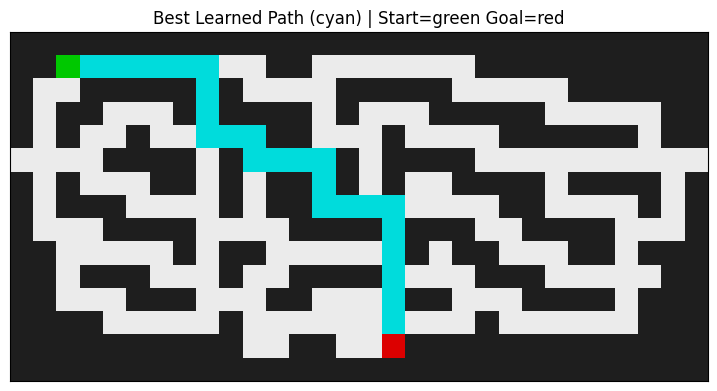

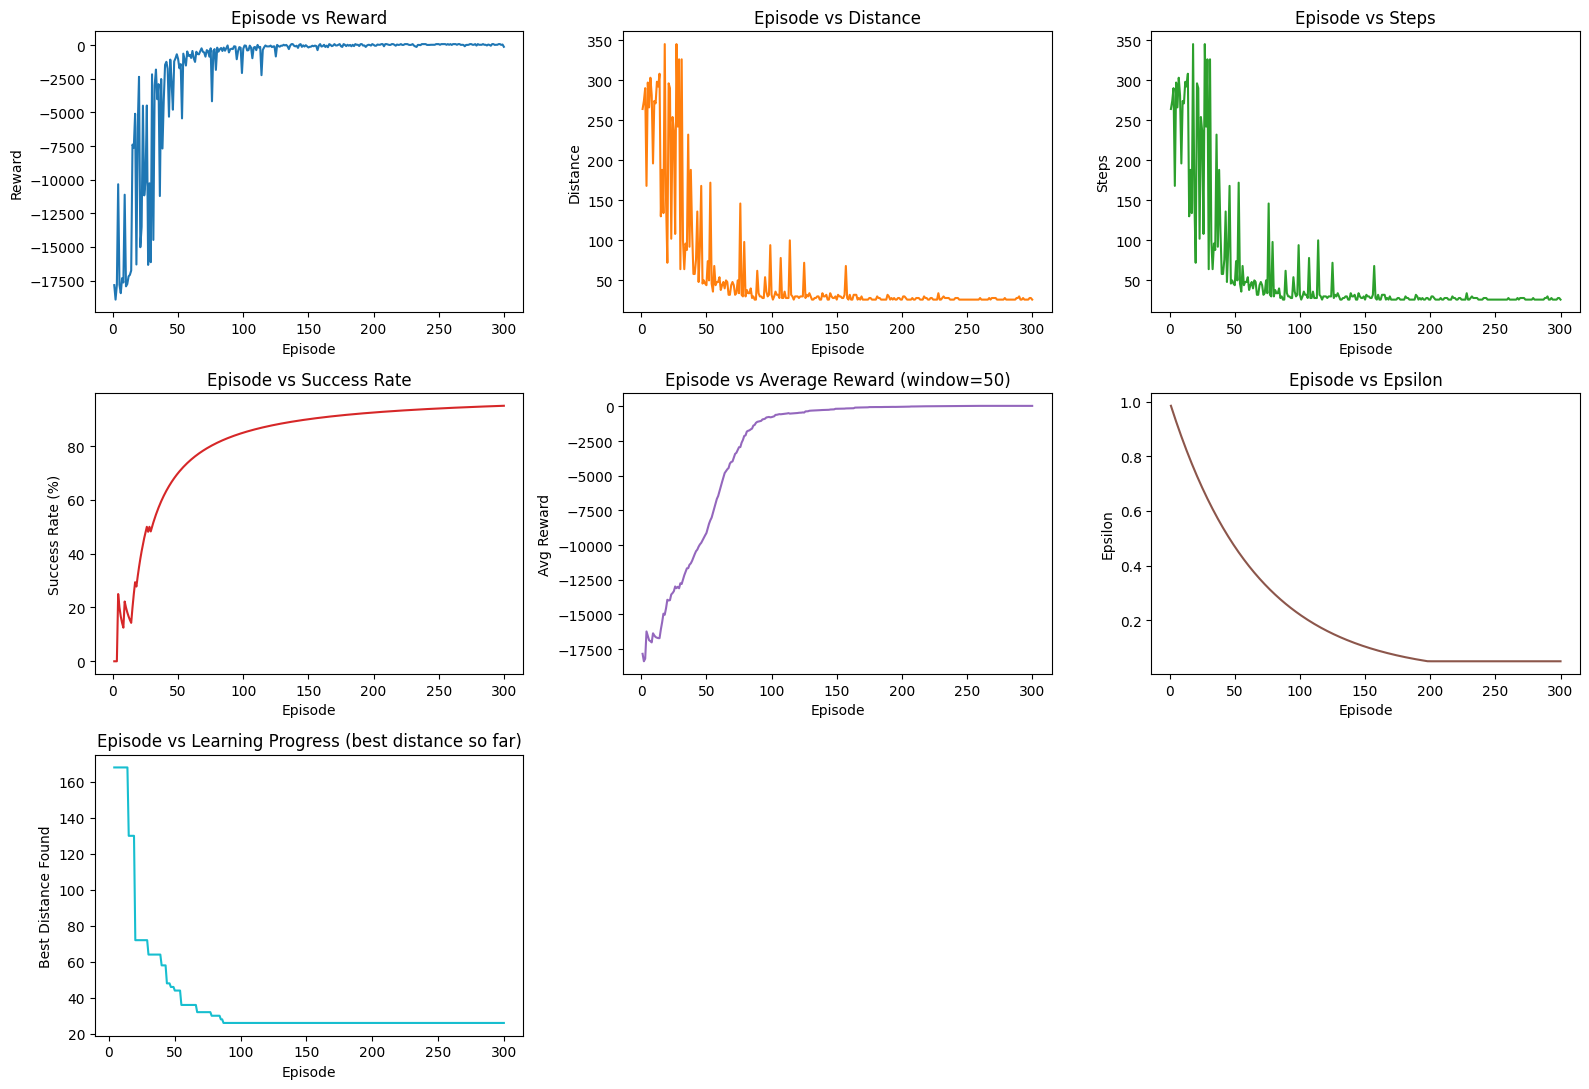

In [1]:
# =============================================================================
# REINFORCEMENT LEARNING GRID PATHFINDER  (paste this whole cell into Colab)
# -----------------------------------------------------------------------------
# NOTE ON ADAPTATION:
#   The original spec assumed an uploaded IMAGE containing labeled nodes
#   (A, B, C...) and edge distances, to be parsed with OpenCV/PIL.
#   What was actually provided is a raw 0/1 GRID MATRIX (1 = road, 0 = wall),
#   with no image and no explicit node labels / start / goal.
#   This script adapts the exact same requirements (pure Q-learning, no
#   Dijkstra/A*/BFS/etc., full exploration, live visualization, stats,
#   final graphs) to that grid:
#     - Every road cell (value 1) becomes a graph node (auto-labeled N0, N1...)
#     - 4-directional moves between adjacent road cells become edges (distance=1)
#     - Start node = first road cell found scanning the grid top-left to
#       bottom-right; Goal node = last road cell found the same way.
#   Change START_CELL / GOAL_CELL below if you want different start/goal cells.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import random
import time

random.seed(42)
np.random.seed(42)

# -----------------------------------------------------------------------------
# 1) THE MAP  (1 = Road, 0 = Empty Space / Wall)
# -----------------------------------------------------------------------------
map_matrix = [
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,0,0,0,0,0,1,0,1,1,1,1,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0],
    [0,1,0,0,1,1,1,0,1,0,0,0,0,1,0,1,1,1,0,0,0,0,0,1,1,1,1,1,0,0],
    [0,1,0,1,1,0,1,1,1,1,1,0,0,1,1,1,0,1,1,1,1,0,0,0,0,0,0,1,0,0],
    [1,1,1,1,0,0,0,0,1,0,1,1,1,1,0,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1],
    [0,1,0,1,1,1,0,0,1,0,1,0,0,1,0,1,0,1,1,0,0,0,0,1,0,0,0,0,1,0],
    [0,1,0,0,0,1,1,1,1,0,1,0,0,1,1,1,1,1,1,1,1,0,0,1,1,1,1,0,1,0],
    [0,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,1,1,0],
    [0,0,1,1,1,1,1,0,1,0,0,1,1,1,1,1,1,0,1,0,0,1,1,1,0,0,1,0,0,0],
    [0,0,1,0,0,0,1,1,1,0,1,1,0,0,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0],
    [0,0,1,1,1,0,0,0,1,1,1,0,0,1,1,1,1,0,0,1,1,1,0,0,0,0,1,0,0,0],
    [0,0,0,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
]
grid = np.array(map_matrix)
ROWS, COLS = grid.shape

# -----------------------------------------------------------------------------
# 2) BUILD GRAPH FROM GRID (nodes = road cells, edges = 4-directional adjacency)
# -----------------------------------------------------------------------------
road_cells = [(r, c) for r in range(ROWS) for c in range(COLS) if grid[r, c] == 1]
N = len(road_cells)
cell_to_idx = {cell: i for i, cell in enumerate(road_cells)}
labels = [f"N{i}" for i in range(N)]

DELTAS = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # up, down, left, right
ACTION_NAMES = ["UP", "DOWN", "LEFT", "RIGHT"]

# Adjacency matrix (distance = 1 for every grid step)
adjacency_matrix = np.zeros((N, N), dtype=int)
for i, (r, c) in enumerate(road_cells):
    for dr, dc in DELTAS:
        nr, nc = r + dr, c + dc
        if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr, nc] == 1:
            j = cell_to_idx[(nr, nc)]
            adjacency_matrix[i, j] = 1

print("=" * 70)
print(f"Detected {N} road nodes on a {ROWS}x{COLS} grid.")
print("=" * 70)
print("\nAdjacency Matrix (1 = connected, distance 1 per edge):\n")
header = "      " + " ".join(f"{l:>4}" for l in labels[:20]) + (" ..." if N > 20 else "")
print(header)
for i in range(min(N, 20)):
    row_str = " ".join(f"{v:>4}" for v in adjacency_matrix[i][:20])
    print(f"{labels[i]:>4}  {row_str}" + (" ..." if N > 20 else ""))
if N > 20:
    print(f"... (matrix truncated for display; full shape = {adjacency_matrix.shape}, "
          f"available in variable `adjacency_matrix`)")

# -----------------------------------------------------------------------------
# 3) START / GOAL  (auto-selected: first and last road cell found)
# -----------------------------------------------------------------------------
START_CELL = road_cells[0]
GOAL_CELL = road_cells[-1]
start_idx = cell_to_idx[START_CELL]
goal_idx = cell_to_idx[GOAL_CELL]
print(f"\nStart node: {labels[start_idx]} at grid cell {START_CELL}")
print(f"Goal  node: {labels[goal_idx]} at grid cell {GOAL_CELL}")

# -----------------------------------------------------------------------------
# 4) Q-LEARNING SETUP  (agent starts knowing NOTHING -> Q-table all zeros)
# -----------------------------------------------------------------------------
Q = np.zeros((N, 4))

ALPHA = 0.15          # learning rate
GAMMA = 0.9            # discount factor
EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.985

NUM_EPISODES = 300
MAX_STEPS = 500
RENDER_EVERY = 10      # full live-render every N episodes (keeps Colab responsive)

REWARD_GOAL = 100
REWARD_STEP = -1        # cost per unit distance travelled
REWARD_LOOP = -30       # revisiting an already-visited node this episode
REWARD_INVALID = -50    # moving into a wall / off the grid

# -----------------------------------------------------------------------------
# 5) STATISTICS CONTAINERS
# -----------------------------------------------------------------------------
episode_rewards, episode_distances, episode_steps = [], [], []
episode_success, episode_epsilons, episode_avg_rewards = [], [], []

best_path_idx = None
best_distance = None
best_reward = None

explored_paths = {}   # tuple(path_indices) -> (distance, reward)  [successful paths only]

epsilon = EPSILON_START

# -----------------------------------------------------------------------------
# 6) VISUALIZATION HELPERS
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

COLOR_WALL = np.array([30, 30, 30])
COLOR_ROAD = np.array([235, 235, 235])
COLOR_START = np.array([0, 200, 0])
COLOR_GOAL = np.array([220, 0, 0])
COLOR_AGENT = np.array([0, 90, 255])
COLOR_VISITED = np.array([255, 215, 0])
COLOR_BEST = np.array([0, 220, 220])


def render(episode, step, current_idx, visited_set, path_indices, current_reward,
           current_distance, eps, best_path_now, title_extra=""):
    """Draw the grid, coloring: start=green goal=red current=blue visited=yellow best=cyan."""
    img = np.zeros((ROWS, COLS, 3), dtype=np.uint8)
    for r in range(ROWS):
        for c in range(COLS):
            img[r, c] = COLOR_ROAD if grid[r, c] == 1 else COLOR_WALL

    if best_path_now:
        for idx in best_path_now:
            r, c = road_cells[idx]
            img[r, c] = COLOR_BEST

    for idx in visited_set:
        r, c = road_cells[idx]
        img[r, c] = COLOR_VISITED

    sr, sc = road_cells[start_idx]
    gr, gc = road_cells[goal_idx]
    img[sr, sc] = COLOR_START
    img[gr, gc] = COLOR_GOAL

    cr, cc = road_cells[current_idx]
    img[cr, cc] = COLOR_AGENT

    ax.clear()
    ax.imshow(img, interpolation="nearest")
    ax.set_title(
        f"Episode {episode} | Step {step} | eps={eps:.3f}\n"
        f"Reward so far={current_reward} | Distance so far={current_distance} {title_extra}",
        fontsize=10
    )
    ax.set_xticks([]); ax.set_yticks([])
    clear_output(wait=True)
    display_fig = fig
    plt.pause(0.001)


# -----------------------------------------------------------------------------
# 7) TRAINING LOOP  (pure Q-learning; NO Dijkstra/A*/BFS/DFS/Bellman-Ford)
# -----------------------------------------------------------------------------
start_time = time.time()
success_count = 0

for episode in range(1, NUM_EPISODES + 1):
    current = start_idx
    visited = {start_idx}
    path = [start_idx]
    total_reward = 0
    total_distance = 0
    done = False

    do_render = (episode % RENDER_EVERY == 0) or (episode == 1) or (episode == NUM_EPISODES)

    for step in range(1, MAX_STEPS + 1):
        # ---- epsilon-greedy action selection ----
        if random.random() < epsilon:
            action = random.randint(0, 3)          # EXPLORE
        else:
            action = int(np.argmax(Q[current]))     # EXPLOIT

        r, c = road_cells[current]
        dr, dc = DELTAS[action]
        nr, nc = r + dr, c + dc

        if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr, nc] == 1:
            next_idx = cell_to_idx[(nr, nc)]
            if next_idx == goal_idx:
                reward = REWARD_GOAL
                distance_travelled = 1
                done = True
            elif next_idx in visited:
                reward = REWARD_LOOP
                distance_travelled = 1
                done = False
            else:
                reward = REWARD_STEP
                distance_travelled = 1
                done = False
            moved_to = next_idx
        else:
            reward = REWARD_INVALID          # invalid move: wall or off-grid
            distance_travelled = 0
            moved_to = current               # agent stays in place
            done = False

        # ---- Q-learning update ----
        best_next_q = np.max(Q[moved_to])
        old_q = Q[current, action]
        Q[current, action] = old_q + ALPHA * (reward + GAMMA * best_next_q - old_q)

        total_reward += reward
        total_distance += distance_travelled

        if moved_to != current:
            path.append(moved_to)
            visited.add(moved_to)

        # ---- per-move log (printed only for rendered episodes, to stay readable) ----
        if do_render:
            print(f"[Ep {episode:3d} | Step {step:3d}] "
                  f"{labels[current]} --{ACTION_NAMES[action]}--> "
                  f"{'(blocked)' if moved_to == current and reward == REWARD_INVALID else labels[moved_to]} | "
                  f"dist={distance_travelled} | reward={reward:+d} | "
                  f"cum_reward={total_reward:+d} | cum_dist={total_distance} | "
                  f"Q[{labels[current]},{ACTION_NAMES[action]}]: {old_q:.3f} -> {Q[current, action]:.3f}")

        current = moved_to

        if do_render and (step % 3 == 0 or done):
            render(episode, step, current, visited, path, total_reward, total_distance, epsilon,
                   best_path_idx)

        if done:
            break

    success = done
    if success:
        success_count += 1
        path_key = tuple(path)
        if path_key not in explored_paths:
            explored_paths[path_key] = (total_distance, total_reward)
        if best_distance is None or total_distance < best_distance:
            best_distance = total_distance
            best_reward = total_reward
            best_path_idx = path[:]

    # ---- decay epsilon ----
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    # ---- record stats ----
    episode_rewards.append(total_reward)
    episode_distances.append(total_distance)
    episode_steps.append(len(path) - 1)
    episode_success.append(1 if success else 0)
    episode_epsilons.append(epsilon)
    episode_avg_rewards.append(np.mean(episode_rewards[-50:]))

    success_rate = success_count / episode * 100

    if do_render:
        print(f"\n>>> EPISODE {episode} SUMMARY | Success={success} | "
              f"Path={[labels[i] for i in path]} | TotalDistance={total_distance} | "
              f"TotalReward={total_reward} | BestDistance={best_distance} | "
              f"BestReward={best_reward} | SuccessRate={success_rate:.1f}% | "
              f"Epsilon={epsilon:.3f}\n" + "-" * 70)
    elif episode % 25 == 0:
        print(f"Episode {episode:4d}/{NUM_EPISODES} | Success={success} | "
              f"Distance={total_distance:4d} | Reward={total_reward:6d} | "
              f"BestDistance={best_distance} | SuccessRate={success_rate:5.1f}% | Eps={epsilon:.3f}")

training_time = time.time() - start_time

# -----------------------------------------------------------------------------
# 8) FINAL RESULTS
# -----------------------------------------------------------------------------
plt.close(fig)

print("\n" + "=" * 70)
print("FINAL ADJACENCY MATRIX SHAPE:", adjacency_matrix.shape)
print("=" * 70)

print("\nFINAL Q-TABLE (rows=nodes, cols=[UP, DOWN, LEFT, RIGHT]):")
np.set_printoptions(precision=2, suppress=True)
print(Q[:min(N, 25)])
if N > 25:
    print(f"... ({N} total rows; full table is in variable `Q`)")

print(f"\nTotal unique successful paths discovered: {len(explored_paths)}")
sorted_paths = sorted(explored_paths.items(), key=lambda kv: kv[1][0])
print("Top 15 explored paths (sorted by shortest total distance):")
for path_key, (dist, rew) in sorted_paths[:15]:
    print(f"  Path: {[labels[i] for i in path_key]} | Distance={dist} | Reward={rew}")

if best_path_idx:
    print("\n" + "=" * 70)
    print("BEST / SHORTEST LEARNED PATH (discovered only via Reinforcement Learning):")
    print(f"  {[labels[i] for i in best_path_idx]}")
    print(f"  Grid cells: {[road_cells[i] for i in best_path_idx]}")
    print(f"  Total distance: {best_distance}")
    print(f"  Total reward: {best_reward}")
else:
    print("\nGoal was never reached during training — consider increasing NUM_EPISODES or MAX_STEPS.")

print(f"\nTraining time: {training_time:.2f} seconds")
print(f"Total episodes: {NUM_EPISODES}")
print(f"Final success rate: {success_count / NUM_EPISODES * 100:.1f}%")
print("=" * 70)

# -----------------------------------------------------------------------------
# 9) FINAL STATIC MAP WITH BEST PATH HIGHLIGHTED
# -----------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 5))
final_img = np.zeros((ROWS, COLS, 3), dtype=np.uint8)
for r in range(ROWS):
    for c in range(COLS):
        final_img[r, c] = COLOR_ROAD if grid[r, c] == 1 else COLOR_WALL
if best_path_idx:
    for idx in best_path_idx:
        r, c = road_cells[idx]
        final_img[r, c] = COLOR_BEST
sr, sc = road_cells[start_idx]
gr, gc = road_cells[goal_idx]
final_img[sr, sc] = COLOR_START
final_img[gr, gc] = COLOR_GOAL
ax2.imshow(final_img, interpolation="nearest")
ax2.set_title("Best Learned Path (cyan) | Start=green Goal=red")
ax2.set_xticks([]); ax2.set_yticks([])
plt.show()

# -----------------------------------------------------------------------------
# 10) LEARNING CURVES
# -----------------------------------------------------------------------------
fig3, axes = plt.subplots(3, 3, figsize=(16, 11))
episodes_range = range(1, NUM_EPISODES + 1)

axes[0, 0].plot(episodes_range, episode_rewards, color="tab:blue")
axes[0, 0].set_title("Episode vs Reward"); axes[0, 0].set_xlabel("Episode"); axes[0, 0].set_ylabel("Reward")

axes[0, 1].plot(episodes_range, episode_distances, color="tab:orange")
axes[0, 1].set_title("Episode vs Distance"); axes[0, 1].set_xlabel("Episode"); axes[0, 1].set_ylabel("Distance")

axes[0, 2].plot(episodes_range, episode_steps, color="tab:green")
axes[0, 2].set_title("Episode vs Steps"); axes[0, 2].set_xlabel("Episode"); axes[0, 2].set_ylabel("Steps")

cumulative_success_rate = np.cumsum(episode_success) / np.arange(1, NUM_EPISODES + 1) * 100
axes[1, 0].plot(episodes_range, cumulative_success_rate, color="tab:red")
axes[1, 0].set_title("Episode vs Success Rate"); axes[1, 0].set_xlabel("Episode"); axes[1, 0].set_ylabel("Success Rate (%)")

axes[1, 1].plot(episodes_range, episode_avg_rewards, color="tab:purple")
axes[1, 1].set_title("Episode vs Average Reward (window=50)"); axes[1, 1].set_xlabel("Episode"); axes[1, 1].set_ylabel("Avg Reward")

axes[1, 2].plot(episodes_range, episode_epsilons, color="tab:brown")
axes[1, 2].set_title("Episode vs Epsilon"); axes[1, 2].set_xlabel("Episode"); axes[1, 2].set_ylabel("Epsilon")

running_best_distance = np.minimum.accumulate(
    [d if s else np.inf for d, s in zip(episode_distances, episode_success)]
)
running_best_distance = np.where(np.isinf(running_best_distance), np.nan, running_best_distance)
axes[2, 0].plot(episodes_range, running_best_distance, color="tab:cyan")
axes[2, 0].set_title("Episode vs Learning Progress (best distance so far)")
axes[2, 0].set_xlabel("Episode"); axes[2, 0].set_ylabel("Best Distance Found")

axes[2, 1].axis("off")
axes[2, 2].axis("off")

plt.tight_layout()
plt.show()

Grid size: 15 rows x 30 cols  (0-indexed: row 0..14, col 0..29)
Sirf woh cells chalengi jinki value 1 (road) hai.

START point ka (row,col) likho, e.g. 1,2 : 1,2
GOAL point ka (row,col) likho, e.g. 1,2 : 5,30
  Ye point grid ke bahar hai. Row 0-14, Col 0-29 ke andar do.
GOAL point ka (row,col) likho, e.g. 1,2 : 5,29

Start = (1, 2)  |  Goal = (5, 29)
Q-learning agent training shuru ho raha hai (koi shortest-path algorithm use nahi ho raha)...

Episode   50/300 | Success rate so far:  68.0% | Best distance so far: 45
Episode  100/300 | Success rate so far:  84.0% | Best distance so far: 35
Episode  150/300 | Success rate so far:  89.3% | Best distance so far: 35
Episode  200/300 | Success rate so far:  92.0% | Best distance so far: 35
Episode  250/300 | Success rate so far:  93.6% | Best distance so far: 35
Episode  300/300 | Success rate so far:  94.7% | Best distance so far: 35

SHORTEST PATH MILA ((1, 2) -> (5, 29)):
  Nodes : ['N0', 'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N

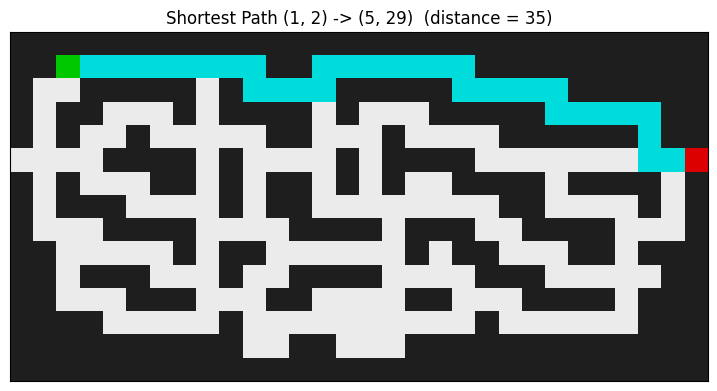

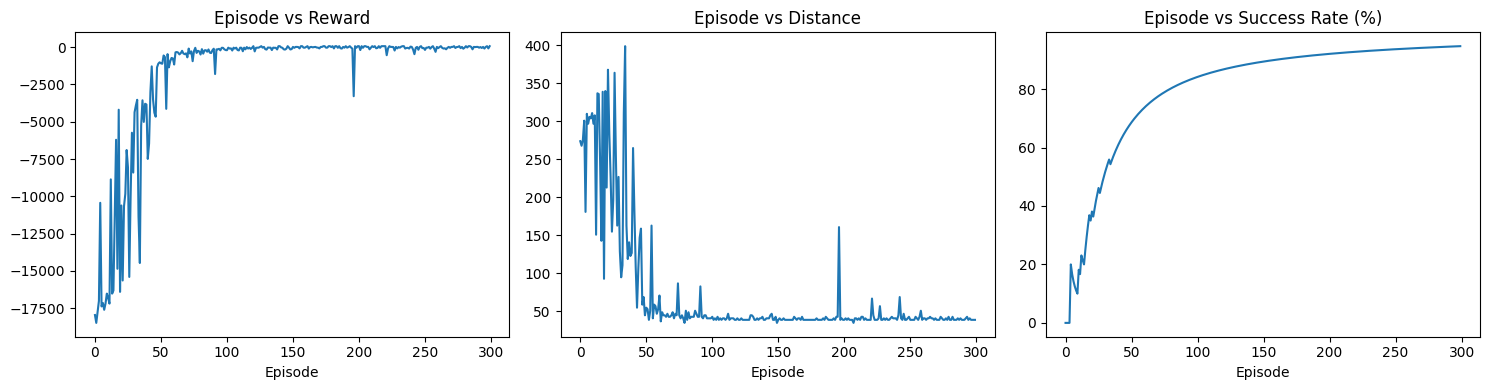

In [3]:
# =============================================================================
# CELL 2 — INTERACTIVE START/GOAL SHORTEST PATH FINDER
# -----------------------------------------------------------------------------
# Ye cell CELL 1 (grid_rl_pathfinder.py) ke baad, SAME notebook session mein
# chalao — kyunki ye grid, road_cells, cell_to_idx, ROWS, COLS, DELTAS,
# ACTION_NAMES aur colors wahi use karta hai jo Cell 1 mein bane the.
#
# Ye cell aap se poochta hai: START point kaunsa aur GOAL point kaunsa hai
# (row,col format mein). Phir sirf UN DO points ke darmiyan Q-learning se
# (Dijkstra/A*/BFS nahi) shortest path dhoondta hai aur visualize karta hai.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import random
import time

# -----------------------------------------------------------------------------
# 1) USER SE START / GOAL POOCHNA
# -----------------------------------------------------------------------------
print(f"Grid size: {ROWS} rows x {COLS} cols  (0-indexed: row 0..{ROWS-1}, col 0..{COLS-1})")
print("Sirf woh cells chalengi jinki value 1 (road) hai.\n")


def ask_point(label):
    while True:
        raw = input(f"{label} point ka (row,col) likho, e.g. 1,2 : ").strip()
        try:
            r_str, c_str = raw.split(",")
            r, c = int(r_str.strip()), int(c_str.strip())
        except Exception:
            print("  Format ghalat hai. 'row,col' likho, e.g. 4,8")
            continue
        if not (0 <= r < ROWS and 0 <= c < COLS):
            print(f"  Ye point grid ke bahar hai. Row 0-{ROWS-1}, Col 0-{COLS-1} ke andar do.")
            continue
        if grid[r, c] != 1:
            print("  Ye cell road (1) nahi, wall/empty (0) hai. Doosra point do.")
            continue
        return (r, c)


start_cell = ask_point("START")
goal_cell = ask_point("GOAL")

if start_cell == goal_cell:
    print("\nStart aur Goal same point hain — distance 0.")
else:
    start_idx = cell_to_idx[start_cell]
    goal_idx = cell_to_idx[goal_cell]

    print(f"\nStart = {start_cell}  |  Goal = {goal_cell}")
    print("Q-learning agent training shuru ho raha hai (koi shortest-path algorithm use nahi ho raha)...\n")

    # -------------------------------------------------------------------------
    # 2) FRESH Q-TABLE + TRAINING SIRF ISI START->GOAL KE LIYE
    # -------------------------------------------------------------------------
    N = len(road_cells)
    Q2 = np.zeros((N, 4))

    ALPHA2 = 0.15
    GAMMA2 = 0.9
    EPSILON2 = 1.0
    EPSILON_MIN2 = 0.05
    EPSILON_DECAY2 = 0.98

    NUM_EPISODES2 = 300
    MAX_STEPS2 = 500

    REWARD_GOAL2 = 100
    REWARD_STEP2 = -1
    REWARD_LOOP2 = -30
    REWARD_INVALID2 = -50

    best_path2 = None
    best_distance2 = None
    success_count2 = 0
    ep_rewards2, ep_distances2, ep_success2 = [], [], []

    start_time2 = time.time()

    for episode in range(1, NUM_EPISODES2 + 1):
        current = start_idx
        visited = {start_idx}
        path = [start_idx]
        total_reward = 0
        total_distance = 0
        done = False

        for step in range(MAX_STEPS2):
            if random.random() < EPSILON2:
                action = random.randint(0, 3)
            else:
                action = int(np.argmax(Q2[current]))

            r, c = road_cells[current]
            dr, dc = DELTAS[action]
            nr, nc = r + dr, c + dc

            if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr, nc] == 1:
                next_idx = cell_to_idx[(nr, nc)]
                if next_idx == goal_idx:
                    reward, dist, done = REWARD_GOAL2, 1, True
                elif next_idx in visited:
                    reward, dist, done = REWARD_LOOP2, 1, False
                else:
                    reward, dist, done = REWARD_STEP2, 1, False
                moved_to = next_idx
            else:
                reward, dist, done = REWARD_INVALID2, 0, False
                moved_to = current

            best_next_q = np.max(Q2[moved_to])
            Q2[current, action] += ALPHA2 * (reward + GAMMA2 * best_next_q - Q2[current, action])

            total_reward += reward
            total_distance += dist

            if moved_to != current:
                path.append(moved_to)
                visited.add(moved_to)
            current = moved_to

            if done:
                break

        if done:
            success_count2 += 1
            if best_distance2 is None or total_distance < best_distance2:
                best_distance2 = total_distance
                best_path2 = path[:]

        EPSILON2 = max(EPSILON_MIN2, EPSILON2 * EPSILON_DECAY2)
        ep_rewards2.append(total_reward)
        ep_distances2.append(total_distance)
        ep_success2.append(1 if done else 0)

        if episode % 50 == 0 or episode == NUM_EPISODES2:
            sr = success_count2 / episode * 100
            print(f"Episode {episode:4d}/{NUM_EPISODES2} | Success rate so far: {sr:5.1f}% | "
                  f"Best distance so far: {best_distance2}")

    training_time2 = time.time() - start_time2

    # -------------------------------------------------------------------------
    # 3) RESULT PRINT KARNA
    # -------------------------------------------------------------------------
    print("\n" + "=" * 60)
    if best_path2:
        labels2 = [f"N{i}" for i in best_path2]
        print(f"SHORTEST PATH MILA ({start_cell} -> {goal_cell}):")
        print(f"  Nodes : {labels2}")
        print(f"  Cells : {[road_cells[i] for i in best_path2]}")
        print(f"  Total distance : {best_distance2}")
    else:
        print("Is start/goal ke darmiyan training ke andar koi safal path nahi mila.")
        print("NUM_EPISODES2 ya MAX_STEPS2 badha kar dobara try karo.")
    print(f"Training time : {training_time2:.2f} sec | Episodes : {NUM_EPISODES2} | "
          f"Success rate : {success_count2 / NUM_EPISODES2 * 100:.1f}%")
    print("=" * 60)

    # -------------------------------------------------------------------------
    # 4) VISUALIZATION — grid par shortest path highlight
    # -------------------------------------------------------------------------
    COLOR_WALL = np.array([30, 30, 30])
    COLOR_ROAD = np.array([235, 235, 235])
    COLOR_START = np.array([0, 200, 0])
    COLOR_GOAL = np.array([220, 0, 0])
    COLOR_BEST = np.array([0, 220, 220])

    img = np.zeros((ROWS, COLS, 3), dtype=np.uint8)
    for r in range(ROWS):
        for c in range(COLS):
            img[r, c] = COLOR_ROAD if grid[r, c] == 1 else COLOR_WALL

    if best_path2:
        for idx in best_path2:
            r, c = road_cells[idx]
            img[r, c] = COLOR_BEST

    img[start_cell] = COLOR_START
    img[goal_cell] = COLOR_GOAL

    plt.figure(figsize=(9, 5))
    plt.imshow(img, interpolation="nearest")
    title = f"Shortest Path {start_cell} -> {goal_cell}"
    if best_path2:
        title += f"  (distance = {best_distance2})"
    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.show()

    # -------------------------------------------------------------------------
    # 5) LEARNING CURVES (isi start/goal ke liye)
    # -------------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(ep_rewards2); axes[0].set_title("Episode vs Reward")
    axes[1].plot(ep_distances2); axes[1].set_title("Episode vs Distance")
    axes[2].plot(np.cumsum(ep_success2) / np.arange(1, NUM_EPISODES2 + 1) * 100)
    axes[2].set_title("Episode vs Success Rate (%)")
    for ax in axes:
        ax.set_xlabel("Episode")
    plt.tight_layout()
    plt.show()

START = (1, 2)   GOAL = (5, 29)
-----------------------------------------------------------------
RL Agent ka path distance   : 35
BFS (ground-truth) distance : 33
-----------------------------------------------------------------
VERDICT: ⚠️ RL ka path 2 steps LAMBA hai optimal se. Ye SUB-OPTIMAL hai — training abhi poori tarah converge nahi hui.
   Suggestion: NUM_EPISODES2 ya MAX_STEPS2 badhao, ya EPSILON_DECAY2 ko thora slow karo (e.g. 0.99) taake agent zyada explore kare.


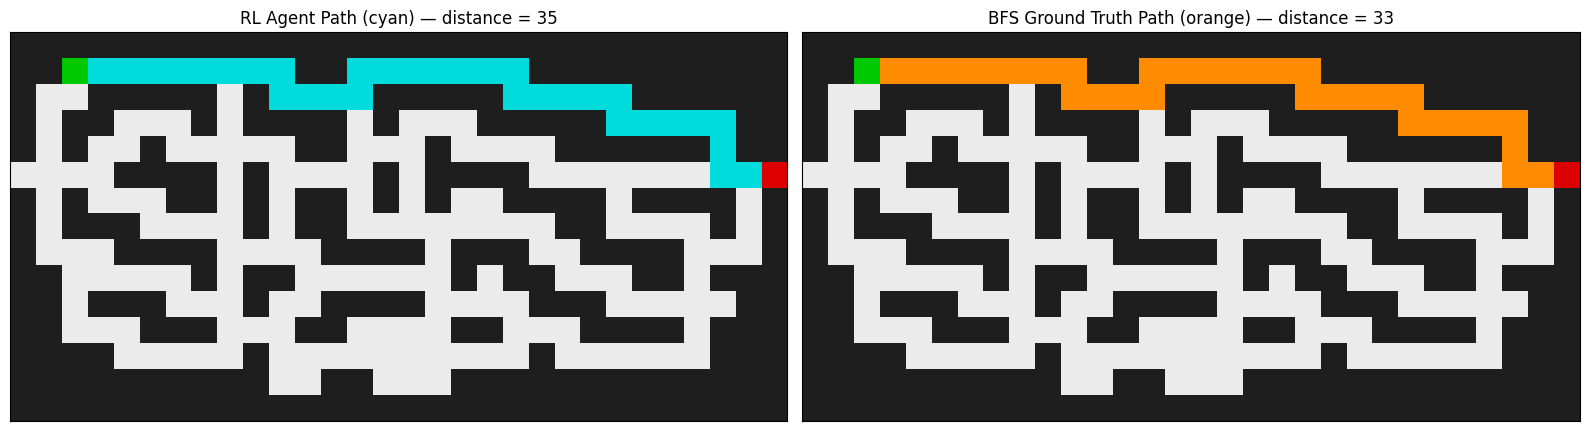

In [4]:
# =============================================================================
# CELL 3 — VERIFICATION: Kya RL wala path sach mein SHORTEST hai?
# -----------------------------------------------------------------------------
# NOTE: Ye BFS sirf VERIFICATION / ANSWER-KEY ke liye hai, RL agent ka hissa
# NAHI hai. Agent ne apna path Cell 2 mein sirf reward/penalty se seekha tha.
# Yahan hum sirf independently check kar rahe hain ke woh answer sahi tha ya
# nahi — jaisay exam mein answer-key se apna paper check karte hain.
#
# BFS is liye reliable checker hai kyunki grid ke saare edges ka weight barabar
# (=1) hai, is liye BFS 100% guaranteed shortest path deta hai.
#
# Ye cell CELL 1 aur CELL 2 ke baad, SAME session mein chalao — kyunki isko
# grid, road_cells, cell_to_idx, start_cell, goal_cell, best_path2,
# best_distance2 (Cell 2 se) chahiye.
# =============================================================================

from collections import deque
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1) INDEPENDENT GROUND-TRUTH: BFS shortest path (sirf checker ke liye)
# -----------------------------------------------------------------------------
def bfs_shortest_path(start, goal):
    """Ye function RL agent se bilkul alag hai — sirf verification ke liye."""
    if start == goal:
        return [start], 0
    visited = {start}
    queue = deque([(start, [start])])
    while queue:
        (r, c), path = queue.popleft()
        for dr, dc in DELTAS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr, nc] == 1 and (nr, nc) not in visited:
                new_path = path + [(nr, nc)]
                if (nr, nc) == goal:
                    return new_path, len(new_path) - 1
                visited.add((nr, nc))
                queue.append(((nr, nc), new_path))
    return None, None   # goal unreachable


bfs_path, bfs_distance = bfs_shortest_path(start_cell, goal_cell)

# -----------------------------------------------------------------------------
# 2) RL KA RESULT NIKALNA (Cell 2 se)
# -----------------------------------------------------------------------------
rl_path_cells = [road_cells[i] for i in best_path2] if best_path2 else None
rl_distance = best_distance2

# -----------------------------------------------------------------------------
# 3) COMPARISON / VERDICT
# -----------------------------------------------------------------------------
print("=" * 65)
print(f"START = {start_cell}   GOAL = {goal_cell}")
print("-" * 65)
print(f"RL Agent ka path distance   : {rl_distance}")
print(f"BFS (ground-truth) distance : {bfs_distance}")
print("-" * 65)

if bfs_distance is None:
    print("VERDICT: Goal khud BFS se bhi unreachable hai — grid/points check karo.")
elif rl_distance is None:
    print("VERDICT: ❌ RL agent ko goal tak koi path nahi mila. "
          "NUM_EPISODES2 / MAX_STEPS2 badha kar Cell 2 dobara chalao.")
elif rl_distance == bfs_distance:
    print("VERDICT: ✅ SAHI! RL agent ne asal mein OPTIMAL shortest path dhoond liya.")
elif rl_distance > bfs_distance:
    diff = rl_distance - bfs_distance
    print(f"VERDICT: ⚠️ RL ka path {diff} steps LAMBA hai optimal se. "
          "Ye SUB-OPTIMAL hai — training abhi poori tarah converge nahi hui.")
    print("   Suggestion: NUM_EPISODES2 ya MAX_STEPS2 badhao, ya EPSILON_DECAY2 "
          "ko thora slow karo (e.g. 0.99) taake agent zyada explore kare.")
else:
    print("VERDICT: Anomaly — RL distance BFS se bhi kam hai, is ka matlab kahin bug hai.")
print("=" * 65)

# -----------------------------------------------------------------------------
# 4) SIDE-BY-SIDE VISUALIZATION: RL path vs BFS (ground truth) path
# -----------------------------------------------------------------------------
COLOR_WALL = np.array([30, 30, 30])
COLOR_ROAD = np.array([235, 235, 235])
COLOR_START = np.array([0, 200, 0])
COLOR_GOAL = np.array([220, 0, 0])
COLOR_RL = np.array([0, 220, 220])      # cyan
COLOR_BFS = np.array([255, 140, 0])     # orange


def build_base_img():
    img = np.zeros((ROWS, COLS, 3), dtype=np.uint8)
    for r in range(ROWS):
        for c in range(COLS):
            img[r, c] = COLOR_ROAD if grid[r, c] == 1 else COLOR_WALL
    return img


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

img_rl = build_base_img()
if rl_path_cells:
    for (r, c) in rl_path_cells:
        img_rl[r, c] = COLOR_RL
img_rl[start_cell] = COLOR_START
img_rl[goal_cell] = COLOR_GOAL
axes[0].imshow(img_rl, interpolation="nearest")
axes[0].set_title(f"RL Agent Path (cyan) — distance = {rl_distance}")
axes[0].set_xticks([]); axes[0].set_yticks([])

img_bfs = build_base_img()
if bfs_path:
    for (r, c) in bfs_path:
        img_bfs[r, c] = COLOR_BFS
img_bfs[start_cell] = COLOR_START
img_bfs[goal_cell] = COLOR_GOAL
axes[1].imshow(img_bfs, interpolation="nearest")
axes[1].set_title(f"BFS Ground Truth Path (orange) — distance = {bfs_distance}")
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.show()


>>> EPISODE 300 SUMMARY | Success=True | Path=['N1', 'N2', 'N23', 'N28', 'N48', 'N55', 'N56', 'N57', 'N73', 'N84', 'N100', 'N109', 'N108', 'N107', 'N125', 'N132', 'N131', 'N130', 'N150', 'N160', 'N177', 'N183', 'N184', 'N185', 'N186', 'N187', 'N188', 'N189', 'N190', 'N191'] | TotalDistance=29 | TotalReward=22 | BestDistance=25 | BestReward=-174 | SuccessRate=92.0% | Epsilon=0.050
----------------------------------------------------------------------

FINAL ADJACENCY MATRIX SHAPE: (205, 205)

FINAL Q-TABLE (rows=nodes, cols=[UP, DOWN, LEFT, RIGHT]):
[[-110.69 -119.97 -116.05  -82.27]
 [ -94.78  -99.42  -83.47  -11.78]
 [ -93.06   -6.99  -63.    -63.49]
 [-107.81 -109.87  -79.45  -59.89]
 [-105.95 -106.01  -87.49  -60.49]
 [ -96.12  -90.54  -85.09  -68.3 ]
 [ -87.3   -79.9   -77.68  -71.5 ]
 [ -82.63  -79.38  -77.    -70.33]
 [ -84.67  -76.58  -75.28  -72.62]
 [ -87.77  -86.61  -76.13  -73.81]
 [ -74.74  -73.21  -71.62  -73.3 ]
 [ -76.93  -76.95  -74.82  -76.91]
 [ -81.58  -78.25  -78.8

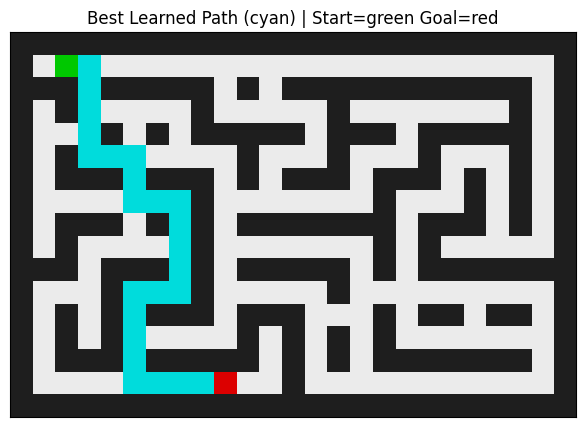

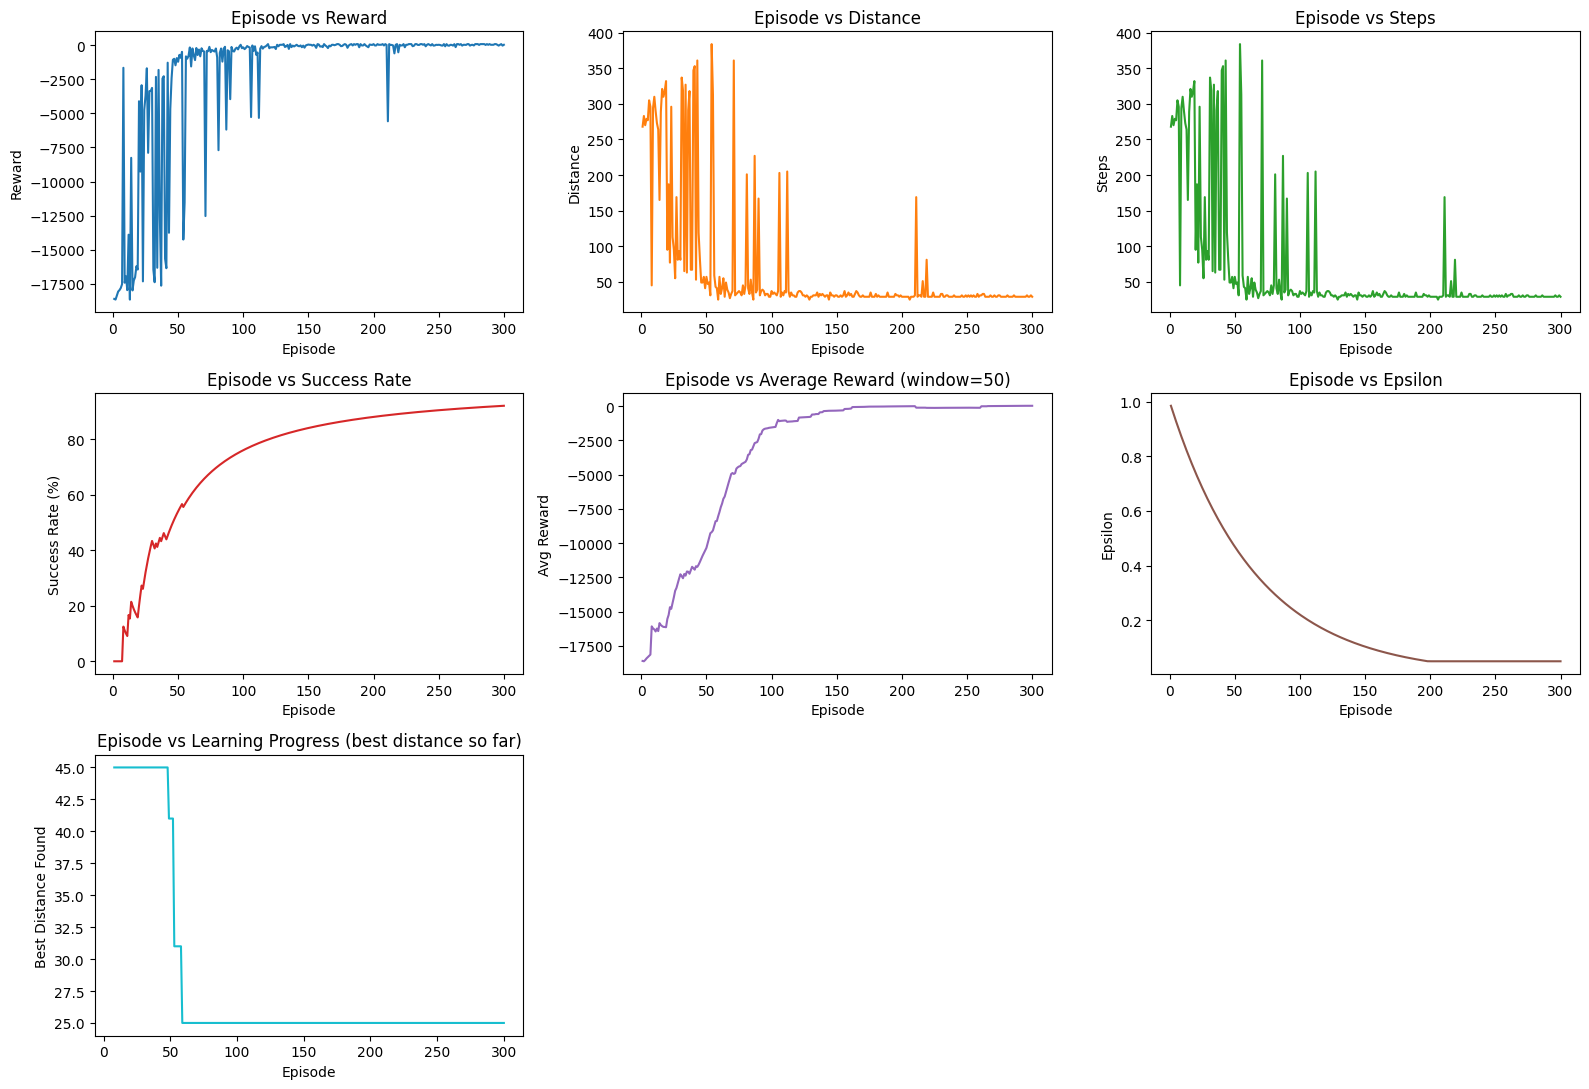

In [15]:
# =============================================================================
# REINFORCEMENT LEARNING GRID PATHFINDER  (paste this whole cell into Colab)
# -----------------------------------------------------------------------------
# NOTE ON ADAPTATION:
#   The original spec assumed an uploaded IMAGE containing labeled nodes
#   (A, B, C...) and edge distances, to be parsed with OpenCV/PIL.
#   What was actually provided is a raw 0/1 GRID MATRIX (1 = road, 0 = wall),
#   with no image and no explicit node labels / start / goal.
#   This script adapts the exact same requirements (pure Q-learning, no
#   Dijkstra/A*/BFS/etc., full exploration, live visualization, stats,
#   final graphs) to that grid:
#     - Every road cell (value 1) becomes a graph node (auto-labeled N0, N1...)
#     - 4-directional moves between adjacent road cells become edges (distance=1)
#     - Start node = first road cell found scanning the grid top-left to
#       bottom-right; Goal node = last road cell found the same way.
#   Change START_CELL / GOAL_CELL below if you want different start/goal cells.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import random
import time

random.seed(42)
np.random.seed(42)

# -----------------------------------------------------------------------------
# 1) THE MAP  (1 = Road, 0 = Empty Space / Wall)
# -----------------------------------------------------------------------------
map_matrix = [
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0],
    [0,1,0,1,1,1,1,1,0,1,1,1,1,1,0,1,1,1,1,1,1,1,0,1,0],
    [0,1,1,1,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0],
    [0,1,0,1,1,1,1,1,1,1,0,1,1,1,0,1,1,1,0,1,1,1,0,1,0],
    [0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,1,0],
    [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0,1,1,1,0,1,0,1,0],
    [0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0],
    [0,1,0,1,1,1,1,1,0,1,1,1,1,1,1,1,0,1,0,1,1,1,1,1,0],
    [0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0],
    [0,1,1,1,0,1,1,1,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,0],
    [0,1,0,1,0,1,0,0,0,1,0,0,0,1,1,1,0,1,0,0,1,0,0,1,0],
    [0,1,0,1,0,1,1,1,1,1,0,1,0,1,0,1,0,1,1,1,1,1,1,1,0],
    [0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
]
grid = np.array(map_matrix)
ROWS, COLS = grid.shape

# -----------------------------------------------------------------------------
# 2) BUILD GRAPH FROM GRID (nodes = road cells, edges = 4-directional adjacency)
# -----------------------------------------------------------------------------
road_cells = [(r, c) for r in range(ROWS) for c in range(COLS) if grid[r, c] == 1]
N = len(road_cells)
cell_to_idx = {cell: i for i, cell in enumerate(road_cells)}
labels = [f"N{i}" for i in range(N)]

DELTAS = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # up, down, left, right
ACTION_NAMES = ["UP", "DOWN", "LEFT", "RIGHT"]

# Adjacency matrix (distance = 1 for every grid step)
adjacency_matrix = np.zeros((N, N), dtype=int)
for i, (r, c) in enumerate(road_cells):
    for dr, dc in DELTAS:
        nr, nc = r + dr, c + dc
        if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr, nc] == 1:
            j = cell_to_idx[(nr, nc)]
            adjacency_matrix[i, j] = 1

print("=" * 70)
print(f"Detected {N} road nodes on a {ROWS}x{COLS} grid.")
print("=" * 70)
print("\nAdjacency Matrix (1 = connected, distance 1 per edge):\n")
header = "      " + " ".join(f"{l:>4}" for l in labels[:20]) + (" ..." if N > 20 else "")
print(header)
for i in range(min(N, 20)):
    row_str = " ".join(f"{v:>4}" for v in adjacency_matrix[i][:20])
    print(f"{labels[i]:>4}  {row_str}" + (" ..." if N > 20 else ""))
if N > 20:
    print(f"... (matrix truncated for display; full shape = {adjacency_matrix.shape}, "
          f"available in variable `adjacency_matrix`)")

# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# 3) START / GOAL  (fixed manually — top-left area to bottom-right area)
# -----------------------------------------------------------------------------
START_CELL = (1, 2)      # <-- start point
GOAL_CELL  = (15, 9)     # <-- goal point
start_idx = cell_to_idx[START_CELL]
goal_idx = cell_to_idx[GOAL_CELL]
print(f"\nStart node: {labels[start_idx]} at grid cell {START_CELL}")
print(f"Goal  node: {labels[goal_idx]} at grid cell {GOAL_CELL}")

# -----------------------------------------------------------------------------
# 4) Q-LEARNING SETUP  (agent starts knowing NOTHING -> Q-table all zeros)
# -----------------------------------------------------------------------------
Q = np.zeros((N, 4))

ALPHA = 0.15          # learning rate
GAMMA = 0.9            # discount factor
EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.985

NUM_EPISODES = 300
MAX_STEPS = 500
RENDER_EVERY = 10      # full live-render every N episodes (keeps Colab responsive)

REWARD_GOAL = 100
REWARD_STEP = -1        # cost per unit distance travelled
REWARD_LOOP = -30       # revisiting an already-visited node this episode
REWARD_INVALID = -50    # moving into a wall / off the grid

# -----------------------------------------------------------------------------
# 5) STATISTICS CONTAINERS
# -----------------------------------------------------------------------------
episode_rewards, episode_distances, episode_steps = [], [], []
episode_success, episode_epsilons, episode_avg_rewards = [], [], []

best_path_idx = None
best_distance = None
best_reward = None

explored_paths = {}   # tuple(path_indices) -> (distance, reward)  [successful paths only]

epsilon = EPSILON_START

# -----------------------------------------------------------------------------
# 6) VISUALIZATION HELPERS
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

COLOR_WALL = np.array([30, 30, 30])
COLOR_ROAD = np.array([235, 235, 235])
COLOR_START = np.array([0, 200, 0])
COLOR_GOAL = np.array([220, 0, 0])
COLOR_AGENT = np.array([0, 90, 255])
COLOR_VISITED = np.array([255, 215, 0])
COLOR_BEST = np.array([0, 220, 220])


def render(episode, step, current_idx, visited_set, path_indices, current_reward,
           current_distance, eps, best_path_now, title_extra=""):
    """Draw the grid, coloring: start=green goal=red current=blue visited=yellow best=cyan."""
    img = np.zeros((ROWS, COLS, 3), dtype=np.uint8)
    for r in range(ROWS):
        for c in range(COLS):
            img[r, c] = COLOR_ROAD if grid[r, c] == 1 else COLOR_WALL

    if best_path_now:
        for idx in best_path_now:
            r, c = road_cells[idx]
            img[r, c] = COLOR_BEST

    for idx in visited_set:
        r, c = road_cells[idx]
        img[r, c] = COLOR_VISITED

    sr, sc = road_cells[start_idx]
    gr, gc = road_cells[goal_idx]
    img[sr, sc] = COLOR_START
    img[gr, gc] = COLOR_GOAL

    cr, cc = road_cells[current_idx]
    img[cr, cc] = COLOR_AGENT

    ax.clear()
    ax.imshow(img, interpolation="nearest")
    ax.set_title(
        f"Episode {episode} | Step {step} | eps={eps:.3f}\n"
        f"Reward so far={current_reward} | Distance so far={current_distance} {title_extra}",
        fontsize=10
    )
    ax.set_xticks([]); ax.set_yticks([])
    clear_output(wait=True)
    display_fig = fig
    plt.pause(0.001)


# -----------------------------------------------------------------------------
# 7) TRAINING LOOP  (pure Q-learning; NO Dijkstra/A*/BFS/DFS/Bellman-Ford)
# -----------------------------------------------------------------------------
start_time = time.time()
success_count = 0

for episode in range(1, NUM_EPISODES + 1):
    current = start_idx
    visited = {start_idx}
    path = [start_idx]
    total_reward = 0
    total_distance = 0
    done = False

    do_render = (episode % RENDER_EVERY == 0) or (episode == 1) or (episode == NUM_EPISODES)

    for step in range(1, MAX_STEPS + 1):
        # ---- epsilon-greedy action selection ----
        if random.random() < epsilon:
            action = random.randint(0, 3)          # EXPLORE
        else:
            action = int(np.argmax(Q[current]))     # EXPLOIT

        r, c = road_cells[current]
        dr, dc = DELTAS[action]
        nr, nc = r + dr, c + dc

        if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr, nc] == 1:
            next_idx = cell_to_idx[(nr, nc)]
            if next_idx == goal_idx:
                reward = REWARD_GOAL
                distance_travelled = 1
                done = True
            elif next_idx in visited:
                reward = REWARD_LOOP
                distance_travelled = 1
                done = False
            else:
                reward = REWARD_STEP
                distance_travelled = 1
                done = False
            moved_to = next_idx
        else:
            reward = REWARD_INVALID          # invalid move: wall or off-grid
            distance_travelled = 0
            moved_to = current               # agent stays in place
            done = False

        # ---- Q-learning update ----
        best_next_q = np.max(Q[moved_to])
        old_q = Q[current, action]
        Q[current, action] = old_q + ALPHA * (reward + GAMMA * best_next_q - old_q)

        total_reward += reward
        total_distance += distance_travelled

        if moved_to != current:
            path.append(moved_to)
            visited.add(moved_to)

        # ---- per-move log (printed only for rendered episodes, to stay readable) ----
        if do_render:
            print(f"[Ep {episode:3d} | Step {step:3d}] "
                  f"{labels[current]} --{ACTION_NAMES[action]}--> "
                  f"{'(blocked)' if moved_to == current and reward == REWARD_INVALID else labels[moved_to]} | "
                  f"dist={distance_travelled} | reward={reward:+d} | "
                  f"cum_reward={total_reward:+d} | cum_dist={total_distance} | "
                  f"Q[{labels[current]},{ACTION_NAMES[action]}]: {old_q:.3f} -> {Q[current, action]:.3f}")

        current = moved_to

        if do_render and (step % 3 == 0 or done):
            render(episode, step, current, visited, path, total_reward, total_distance, epsilon,
                   best_path_idx)

        if done:
            break

    success = done
    if success:
        success_count += 1
        path_key = tuple(path)
        if path_key not in explored_paths:
            explored_paths[path_key] = (total_distance, total_reward)
        if best_distance is None or total_distance < best_distance:
            best_distance = total_distance
            best_reward = total_reward
            best_path_idx = path[:]

    # ---- decay epsilon ----
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    # ---- record stats ----
    episode_rewards.append(total_reward)
    episode_distances.append(total_distance)
    episode_steps.append(len(path) - 1)
    episode_success.append(1 if success else 0)
    episode_epsilons.append(epsilon)
    episode_avg_rewards.append(np.mean(episode_rewards[-50:]))

    success_rate = success_count / episode * 100

    if do_render:
        print(f"\n>>> EPISODE {episode} SUMMARY | Success={success} | "
              f"Path={[labels[i] for i in path]} | TotalDistance={total_distance} | "
              f"TotalReward={total_reward} | BestDistance={best_distance} | "
              f"BestReward={best_reward} | SuccessRate={success_rate:.1f}% | "
              f"Epsilon={epsilon:.3f}\n" + "-" * 70)
    elif episode % 25 == 0:
        print(f"Episode {episode:4d}/{NUM_EPISODES} | Success={success} | "
              f"Distance={total_distance:4d} | Reward={total_reward:6d} | "
              f"BestDistance={best_distance} | SuccessRate={success_rate:5.1f}% | Eps={epsilon:.3f}")

training_time = time.time() - start_time

# -----------------------------------------------------------------------------
# 8) FINAL RESULTS
# -----------------------------------------------------------------------------
plt.close(fig)

print("\n" + "=" * 70)
print("FINAL ADJACENCY MATRIX SHAPE:", adjacency_matrix.shape)
print("=" * 70)

print("\nFINAL Q-TABLE (rows=nodes, cols=[UP, DOWN, LEFT, RIGHT]):")
np.set_printoptions(precision=2, suppress=True)
print(Q[:min(N, 25)])
if N > 25:
    print(f"... ({N} total rows; full table is in variable `Q`)")

print(f"\nTotal unique successful paths discovered: {len(explored_paths)}")
sorted_paths = sorted(explored_paths.items(), key=lambda kv: kv[1][0])
print("Top 15 explored paths (sorted by shortest total distance):")
for path_key, (dist, rew) in sorted_paths[:15]:
    print(f"  Path: {[labels[i] for i in path_key]} | Distance={dist} | Reward={rew}")

if best_path_idx:
    print("\n" + "=" * 70)
    print("BEST / SHORTEST LEARNED PATH (discovered only via Reinforcement Learning):")
    print(f"  {[labels[i] for i in best_path_idx]}")
    print(f"  Grid cells: {[road_cells[i] for i in best_path_idx]}")
    print(f"  Total distance: {best_distance}")
    print(f"  Total reward: {best_reward}")
else:
    print("\nGoal was never reached during training — consider increasing NUM_EPISODES or MAX_STEPS.")

print(f"\nTraining time: {training_time:.2f} seconds")
print(f"Total episodes: {NUM_EPISODES}")
print(f"Final success rate: {success_count / NUM_EPISODES * 100:.1f}%")
print("=" * 70)

# -----------------------------------------------------------------------------
# 9) FINAL STATIC MAP WITH BEST PATH HIGHLIGHTED
# -----------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 5))
final_img = np.zeros((ROWS, COLS, 3), dtype=np.uint8)
for r in range(ROWS):
    for c in range(COLS):
        final_img[r, c] = COLOR_ROAD if grid[r, c] == 1 else COLOR_WALL
if best_path_idx:
    for idx in best_path_idx:
        r, c = road_cells[idx]
        final_img[r, c] = COLOR_BEST
sr, sc = road_cells[start_idx]
gr, gc = road_cells[goal_idx]
final_img[sr, sc] = COLOR_START
final_img[gr, gc] = COLOR_GOAL
ax2.imshow(final_img, interpolation="nearest")
ax2.set_title("Best Learned Path (cyan) | Start=green Goal=red")
ax2.set_xticks([]); ax2.set_yticks([])
plt.show()

# -----------------------------------------------------------------------------
# 10) LEARNING CURVES
# -----------------------------------------------------------------------------
fig3, axes = plt.subplots(3, 3, figsize=(16, 11))
episodes_range = range(1, NUM_EPISODES + 1)

axes[0, 0].plot(episodes_range, episode_rewards, color="tab:blue")
axes[0, 0].set_title("Episode vs Reward"); axes[0, 0].set_xlabel("Episode"); axes[0, 0].set_ylabel("Reward")

axes[0, 1].plot(episodes_range, episode_distances, color="tab:orange")
axes[0, 1].set_title("Episode vs Distance"); axes[0, 1].set_xlabel("Episode"); axes[0, 1].set_ylabel("Distance")

axes[0, 2].plot(episodes_range, episode_steps, color="tab:green")
axes[0, 2].set_title("Episode vs Steps"); axes[0, 2].set_xlabel("Episode"); axes[0, 2].set_ylabel("Steps")

cumulative_success_rate = np.cumsum(episode_success) / np.arange(1, NUM_EPISODES + 1) * 100
axes[1, 0].plot(episodes_range, cumulative_success_rate, color="tab:red")
axes[1, 0].set_title("Episode vs Success Rate"); axes[1, 0].set_xlabel("Episode"); axes[1, 0].set_ylabel("Success Rate (%)")

axes[1, 1].plot(episodes_range, episode_avg_rewards, color="tab:purple")
axes[1, 1].set_title("Episode vs Average Reward (window=50)"); axes[1, 1].set_xlabel("Episode"); axes[1, 1].set_ylabel("Avg Reward")

axes[1, 2].plot(episodes_range, episode_epsilons, color="tab:brown")
axes[1, 2].set_title("Episode vs Epsilon"); axes[1, 2].set_xlabel("Episode"); axes[1, 2].set_ylabel("Epsilon")

running_best_distance = np.minimum.accumulate(
    [d if s else np.inf for d, s in zip(episode_distances, episode_success)]
)
running_best_distance = np.where(np.isinf(running_best_distance), np.nan, running_best_distance)
axes[2, 0].plot(episodes_range, running_best_distance, color="tab:cyan")
axes[2, 0].set_title("Episode vs Learning Progress (best distance so far)")
axes[2, 0].set_xlabel("Episode"); axes[2, 0].set_ylabel("Best Distance Found")

axes[2, 1].axis("off")
axes[2, 2].axis("off")

plt.tight_layout()
plt.show()